# Raising the Bar of AI-generated Image Detection with CLIP
### A from-scratch recreation of Cozzolino et al., CVPRW 2024 (arXiv:[2312.00195](https://arxiv.org/abs/2312.00195))

This notebook recreates the detector from **"Raising the Bar of AI-generated Image Detection with CLIP"** (Cozzolino, Poggi, Corvi, Nießner, Verdoliva), and then benchmarks it against a couple of **related-work baselines** so you can see *why* the paper's approach works, not just that it does.

**The paper's core finding:** you don't need a huge domain-specific training set to detect AI-generated images. A linear SVM trained on the *penultimate-layer* features of a frozen, off-the-shelf CLIP ViT-L/14 — using as few as 10–100 example images per class — generalizes remarkably well across GANs, diffusion models, and commercial tools (DALL·E 3, Midjourney, Firefly), and is unusually robust to JPEG compression, resizing, and cropping.

This recreation is grounded directly in the **official implementation** (github.com/grip-unina/ClipBased-SyntheticImageDetection) — I cloned it and read the actual feature-extraction code to make sure the "next-to-last layer" trick below is implemented exactly as the authors do it, not just as I'd guess from the paper text alone.

**What you'll build, in order:**
1. The CLIP feature extractor (the paper's core trick)
2. A data pipeline (your own images, or an auto-downloaded demo set)
3. The reference-set + linear-SVM training procedure
4. The paper's evaluation protocol (AUC / AP / Balanced Accuracy)
5. The "how much data do you actually need?" experiment (recreates Fig. 3)
6. The paper's robustness test (random crop + resize + JPEG re-compression)
7. **Related-papers comparison:** an ImageNet-ResNet50 baseline (classic CNN forensics lineage) and a hand-crafted frequency-domain baseline (classic spectral forensics lineage), run through the *same* pipeline so the comparison is apples-to-apples
8. Score fusion (the paper's Section 6 idea)
9. *(Bonus, optional)* loading the authors' own released weights to sanity-check this recreation

> **Runtime tip:** go to `Runtime → Change runtime type` and pick a GPU (T4 is fine) before running. Feature extraction is much faster on GPU (~10 min total) than CPU (~45+ min). Run the cells top to bottom — later cells depend on variables defined earlier.

## 0. Setup

In [ ]:
!pip install -q open_clip_torch huggingface_hub datasets scikit-learn scipy pandas matplotlib tqdm joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


In [ ]:
import os, glob, io, random, subprocess, sys
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as tv_models

import open_clip

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score

from tqdm.auto import tqdm

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG = {
    "pretrained_tag": "clipL14openai",   # see the dict below for alternatives (Fig. 4 of the paper)
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 32,
    "max_reference_pairs": 200,          # N: reference images per class used to fit the SVM
    "test_pairs": 100,                   # held-out images per class, never used for training
    "seed": SEED,
}

print("Device:", CONFIG["device"])
if CONFIG["device"] == "cpu":
    print("No GPU detected -- Runtime > Change runtime type > GPU is strongly recommended.")
else:
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 1. The core idea: CLIP's *next-to-last* layer

CLIP's image encoder (ViT-L/14) ends with: `transformer blocks -> final LayerNorm -> take the [CLS] token -> project it into the 768-d image-text joint embedding space`. That last projection is what CLIP uses for image-text similarity — but the paper's key finding is that the representation **one step earlier** (1024-d, before the projection) is a better forensic feature: it hasn't been squeezed down to only the information that's useful for matching images to captions, so it retains more of the low-level statistical fingerprints that give away a generative model.

**How to get it in code:** in `open_clip`, the vision transformer's forward pass ends with:
```python
if self.proj is not None:
    pooled = pooled @ self.proj
return pooled
```
So if we simply set `backbone.visual.proj = None` after loading the model, `encode_image()` hands back the pre-projection, 1024-d features instead. That one-line trick *is* the paper's feature extractor. (I confirmed this by reading `networks/openclipnet.py` in the official repo — it does exactly this.)

The paper then: (1) L2-normalizes these features, (2) collects them for a handful of real and fake images (the "reference set"), (3) fits a **linear SVM** on the two clusters, and (4) uses the signed distance from the hyperplane as a real/fake score.

In [ ]:
DICT_PRETRAIN = {
    # tag              : (open_clip arch, pretrained weights)
    "clipL14openai":     ("ViT-L-14", "openai"),              # smallest download, good default
    "clipL14laion400m":  ("ViT-L-14", "laion400m_e32"),
    "clipL14laion2B":    ("ViT-L-14", "laion2b_s32b_b82k"),
    "clipL14commonpool": ("ViT-L-14", "laion/CLIP-ViT-L-14-CommonPool.XL-s13B-b90K"),  # what the authors' released weights use (Fig. 4: best generalization, biggest download)
}


class CLIPFeatureExtractor:
    """
    Recreates the feature extractor from Cozzolino et al. 2023 (arXiv:2312.00195).
    Loads a CLIP ViT-L/14 image encoder and extracts the *next-to-last* layer
    representation (pooled transformer output before the final projection into
    the shared image-text embedding space), then L2-normalizes it.
    """

    def __init__(self, pretrained_tag="clipL14openai", device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.arch, pretrained = DICT_PRETRAIN[pretrained_tag]

        if pretrained.startswith("laion/"):
            from huggingface_hub import hf_hub_download
            weight_path = hf_hub_download(pretrained, "open_clip_pytorch_model.bin")
            backbone = open_clip.create_model(self.arch, pretrained=weight_path)
        else:
            backbone = open_clip.create_model(self.arch, pretrained=pretrained)

        # --- the key trick: delete the final projection ---
        self.num_features = backbone.visual.proj.shape[0]
        backbone.visual.proj = None

        backbone.eval().to(self.device)
        self.backbone = backbone

        self.preprocess = transforms.Compose([
            transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                                  std=(0.26862954, 0.26130258, 0.27577711)),
        ])

    @torch.no_grad()
    def extract_from_images(self, pil_images, batch_size=32, show_progress=True, desc="CLIP features"):
        feats = []
        iterator = range(0, len(pil_images), batch_size)
        if show_progress:
            iterator = tqdm(iterator, desc=desc)
        for i in iterator:
            batch_imgs = pil_images[i:i + batch_size]
            imgs = [self.preprocess(im.convert("RGB")) for im in batch_imgs]
            batch = torch.stack(imgs, 0).to(self.device)
            f = self.backbone.encode_image(batch, normalize=True)  # L2-normalized, matches the paper
            feats.append(f.cpu().numpy())
        return np.concatenate(feats, axis=0)

    def extract_from_paths(self, paths, batch_size=32, show_progress=True, desc="CLIP features"):
        images = [Image.open(p) for p in paths]
        return self.extract_from_images(images, batch_size=batch_size, show_progress=show_progress, desc=desc)


clip_extractor = CLIPFeatureExtractor(pretrained_tag=CONFIG["pretrained_tag"], device=CONFIG["device"])
print(f"Loaded CLIP {clip_extractor.arch} (pretrained='{CONFIG['pretrained_tag']}')")
print(f"Next-to-last-layer feature dimensionality: {clip_extractor.num_features}")

open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded CLIP ViT-L-14 (pretrained='clipL14openai')
Next-to-last-layer feature dimensionality: 1024


## 2. Get some data: real images + AI-generated images

The pipeline just needs two folders of images: `data/real/` and `data/fake/`. Pick **one or more** of the options below:

- **Option A** — upload your own images (best if you're testing your own generator, which is exactly your use case)
- **Option B** — auto-download a small, ready-made demo set (recommended if you just want everything to run end-to-end right now)
- **Option C** *(bonus, optional)* — a slice of **SynthWildX**, the real-world X/Twitter dataset the paper itself uses for its "few-shot in the wild" experiment

You can mix and match — just make sure images end up in `data/real/` or `data/fake/` (subfolders are fine).

In [ ]:
os.makedirs("data/real", exist_ok=True)
os.makedirs("data/fake", exist_ok=True)


def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".webp", ".bmp")
    paths = [p for p in glob.glob(os.path.join(folder, "**", "*"), recursive=True)
             if p.lower().endswith(exts) and os.path.isfile(p)]
    return sorted(paths)


print("data/real and data/fake are ready. Use Option A, B, and/or C below to fill them.")

data/real and data/fake are ready. Use Option A, B, and/or C below to fill them.


**Option A — upload your own images.** Set `RUN_UPLOAD = True` below, run the cell, and pick files from your computer. You'll then move each upload into `data/real/` or `data/fake/` depending on which it is.

In [ ]:
RUN_UPLOAD = False  # flip to True to use this option

if RUN_UPLOAD:
    try:
        from google.colab import files
        import shutil
        uploaded = files.upload()
        print("\nUploaded:", list(uploaded.keys()))
        print("Now sort them, e.g.:")
        print("  shutil.move('my_photo.jpg', 'data/real/my_photo.jpg')")
        print("  shutil.move('generated_001.png', 'data/fake/generated_001.png')")
    except ImportError:
        print("This upload widget only works inside Google Colab.")
        print("If you're running locally, just copy files directly into data/real/ and data/fake/.")
else:
    print("Skipped (RUN_UPLOAD is False). Set it to True above if you want to upload your own images.")

**Option B — quick-start demo dataset (recommended default).** Pulls a small, balanced slice of a public real-vs-AI-generated image dataset from Hugging Face, so the rest of the notebook has something to run on immediately.

In [ ]:
def download_demo_dataset(n_per_class):
    from datasets import load_dataset
    print(f"Downloading up to {n_per_class} real + {n_per_class} AI-generated demo images...")
    try:
        ds = load_dataset("Parveshiiii/AI-vs-Real", split="train")
    except Exception as e:
        print("Could not download the demo dataset:", repr(e))
        print("No problem -- use Option A to upload your own images instead.")
        return False

    names = ds.features["label"].names
    print("Label classes found in the dataset:", names)
    real_idx = names.index("real")
    ai_idx = names.index("ai")

    ds = ds.shuffle(seed=CONFIG["seed"])
    n_real = n_fake = 0
    for ex in tqdm(ds, desc="Saving demo images"):
        if n_real >= n_per_class and n_fake >= n_per_class:
            break
        label = ex["label"]
        if label == real_idx and n_real < n_per_class:
            ex["image"].convert("RGB").save(f"data/real/demo_{n_real:04d}.jpg", quality=95)
            n_real += 1
        elif label == ai_idx and n_fake < n_per_class:
            ex["image"].convert("RGB").save(f"data/fake/demo_{n_fake:04d}.jpg", quality=95)
            n_fake += 1
    print(f"Saved {n_real} real and {n_fake} AI-generated demo images.")
    return True


download_demo_dataset(n_per_class=CONFIG["max_reference_pairs"] + CONFIG["test_pairs"])

README.md:   0%|          | 0.00/3.06k [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/309M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

Could not download the demo dataset: NonMatchingSplitsSizesError("[{'expected': SplitInfo(name='train', num_bytes=1961367923.889, num_examples=9999, shard_lengths=None, dataset_name=None), 'recorded': SplitInfo(name='train', num_bytes=2166645619, num_examples=13999, shard_lengths=[6500, 1800, 1200, 1000, 3499], dataset_name='ai-vs-real')}]")
No problem -- use Option A to upload your own images instead.


False

**Option C (bonus, optional) — SynthWildX.** A small dataset of 500 real + 1,500 AI-generated (DALL·E 3 / Midjourney / Firefly) images collected from X, used in the paper's own "in the wild" experiment. Images are hotlinked from X's CDN, so some links may have expired — this is best-effort and safe to skip. Not required for the rest of the notebook.

In [ ]:
def download_synthwildx_sample(n_per_type=15, timeout=5):
    list_url = ("https://raw.githubusercontent.com/grip-unina/"
                "ClipBased-SyntheticImageDetection/main/data/synthwildx/list.csv")
    try:
        tab = pd.read_csv(list_url)
    except Exception as e:
        print("Could not reach the SynthWildX file list:", repr(e))
        return

    import urllib.request
    headers = {"User-Agent": "Mozilla/5.0"}
    counts = {}
    for typ, group in tab.groupby("typ"):
        group = group.sample(frac=1, random_state=CONFIG["seed"])
        out_root = "data/real" if typ == "real" else "data/fake"
        out_dir = os.path.join(out_root, "synthwildx_" + typ)
        os.makedirs(out_dir, exist_ok=True)
        saved = 0
        for _, row in group.iterrows():
            if saved >= n_per_type:
                break
            try:
                req = urllib.request.Request(row["url"], headers=headers)
                with urllib.request.urlopen(req, timeout=timeout) as resp:
                    data = resp.read()
                with open(os.path.join(out_dir, os.path.basename(row["filename"])), "wb") as f:
                    f.write(data)
                saved += 1
            except Exception:
                continue
        counts[typ] = saved
    print("Downloaded from SynthWildX:", counts)


# Uncomment to try it (takes a few minutes, and some links will fail -- that's expected):
download_synthwildx_sample(n_per_type=50)

Downloaded from SynthWildX: {'dalle3': 50, 'firefly': 50, 'midjourney_v5': 50, 'real': 50}


**Check what we've got.**

Found 50 real images and 150 fake images.


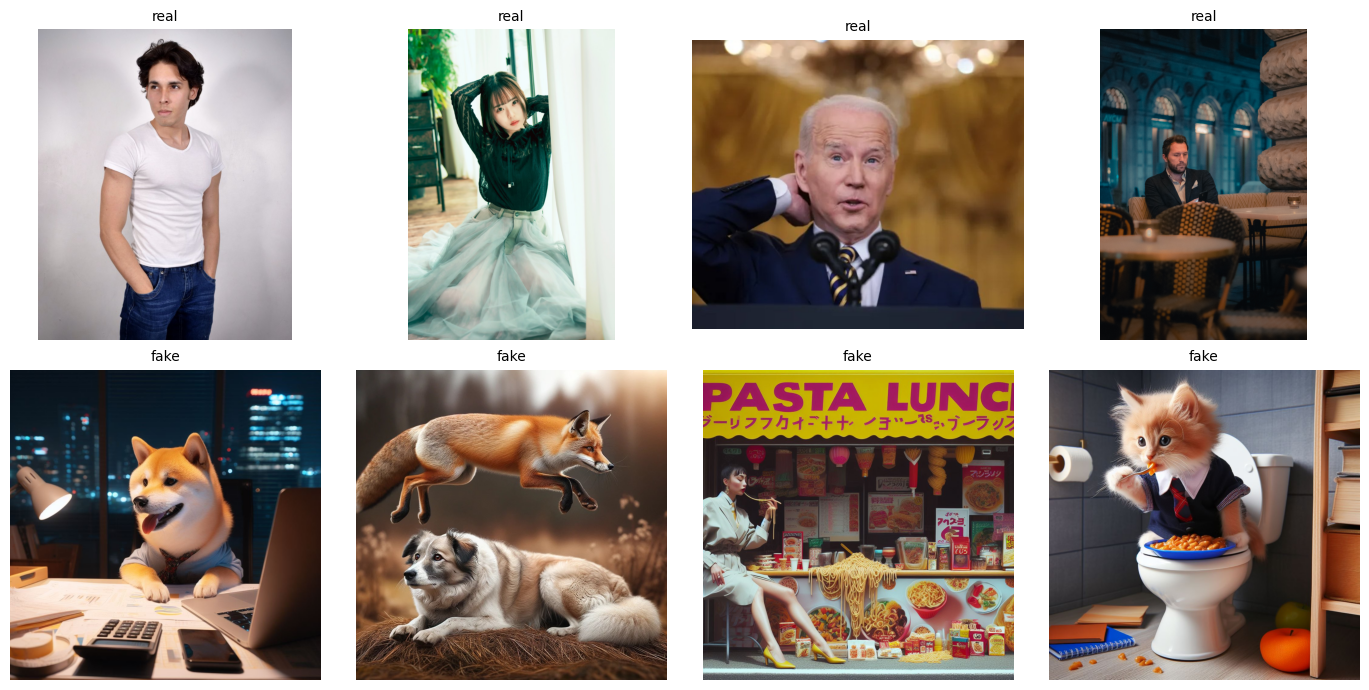

In [ ]:
real_paths = list_images("data/real")
fake_paths = list_images("data/fake")
print(f"Found {len(real_paths)} real images and {len(fake_paths)} fake images.")

assert len(real_paths) >= 20 and len(fake_paths) >= 20, (
    "You need at least ~20 real and ~20 fake images to continue. "
    "Run Option A or Option B above, then re-run this cell."
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, p in zip(axes[0], real_paths[:4]):
    ax.imshow(Image.open(p).convert("RGB")); ax.set_title("real", fontsize=10); ax.axis("off")
for ax, p in zip(axes[1], fake_paths[:4]):
    ax.imshow(Image.open(p).convert("RGB")); ax.set_title("fake", fontsize=10); ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Build the reference set and a held-out test set

We split off a held-out test pool **first**, and only ever train on the remainder — this mirrors good practice generally, and matches the paper's own train/test separation. `CONFIG["max_reference_pairs"]` and `CONFIG["test_pairs"]` are automatically capped to whatever you actually have.

In [ ]:
n_test = min(CONFIG["test_pairs"], len(real_paths) // 3, len(fake_paths) // 3)
n_ref_max = min(CONFIG["max_reference_pairs"], len(real_paths) - n_test, len(fake_paths) - n_test)
CONFIG["test_pairs"] = n_test
CONFIG["max_reference_pairs"] = n_ref_max
print(f"Using {n_ref_max} reference pairs per class and {n_test} held-out test pairs per class.")

real_ref_paths, real_test_paths = train_test_split(real_paths, test_size=n_test, random_state=CONFIG["seed"])
fake_ref_paths, fake_test_paths = train_test_split(fake_paths, test_size=n_test, random_state=CONFIG["seed"])
real_ref_paths = real_ref_paths[:n_ref_max]
fake_ref_paths = fake_ref_paths[:n_ref_max]

print(f"Reference pool : {len(real_ref_paths)} real, {len(fake_ref_paths)} fake")
print(f"Held-out test  : {len(real_test_paths)} real, {len(fake_test_paths)} fake")

Using 34 reference pairs per class and 16 held-out test pairs per class.
Reference pool : 34 real, 34 fake
Held-out test  : 16 real, 16 fake


In [ ]:
real_feats_pool = clip_extractor.extract_from_paths(real_ref_paths, batch_size=CONFIG["batch_size"], desc="CLIP features (real, reference)")
fake_feats_pool = clip_extractor.extract_from_paths(fake_ref_paths, batch_size=CONFIG["batch_size"], desc="CLIP features (fake, reference)")
real_feats_test = clip_extractor.extract_from_paths(real_test_paths, batch_size=CONFIG["batch_size"], desc="CLIP features (real, test)")
fake_feats_test = clip_extractor.extract_from_paths(fake_test_paths, batch_size=CONFIG["batch_size"], desc="CLIP features (fake, test)")

print("Reference pool feature shapes:", real_feats_pool.shape, fake_feats_pool.shape)
print("Held-out test feature shapes :", real_feats_test.shape, fake_feats_test.shape)

CLIP features (real, reference):   0%|          | 0/2 [00:00<?, ?it/s]

CLIP features (fake, reference):   0%|          | 0/2 [00:00<?, ?it/s]

CLIP features (real, test):   0%|          | 0/1 [00:00<?, ?it/s]

CLIP features (fake, test):   0%|          | 0/1 [00:00<?, ?it/s]

Reference pool feature shapes: (34, 1024) (34, 1024)
Held-out test feature shapes : (16, 1024) (16, 1024)


## 4. Train the linear SVM and evaluate

Two implementation notes versus the paper's minimal description:

- The paper trains an **SVM**; at deployment time the authors convert it to an equivalent `Linear` layer (a linear SVM's decision function is just `w·x + b`, so this is an exact conversion, not an approximation). We use `sklearn.svm.LinearSVC`, which optimizes the same objective but scales far better to thousands of samples than kernel-SVM (`SVC(kernel="linear")`) — useful once you push `N` up toward the paper's 1k–10k regime.
- We add a `StandardScaler` before the SVM. This is standard, well-justified practice for linear SVMs in general, and it also makes the multi-backbone comparison in Part 7 fair (the hand-crafted frequency-domain features later on need it much more than CLIP's already-L2-normalized ones).

We report the same three metrics as the paper: **AUC**, **Average Precision**, and **Balanced Accuracy at a fixed 0.5 threshold** (i.e., `score > 0`).

In [ ]:
def train_and_eval(real_feats_ref, fake_feats_ref, real_feats_test, fake_feats_test, C=1.0):
    """Fits a linear SVM on the reference set and evaluates it on a held-out test set."""
    scaler = StandardScaler().fit(np.concatenate([real_feats_ref, fake_feats_ref], axis=0))
    X = scaler.transform(np.concatenate([real_feats_ref, fake_feats_ref], axis=0))
    y = np.concatenate([np.zeros(len(real_feats_ref)), np.ones(len(fake_feats_ref))])  # 0=real, 1=fake

    clf = LinearSVC(C=C, max_iter=20000)
    clf.fit(X, y)

    Xt = scaler.transform(np.concatenate([real_feats_test, fake_feats_test], axis=0))
    yt = np.concatenate([np.zeros(len(real_feats_test)), np.ones(len(fake_feats_test))])
    scores = clf.decision_function(Xt)  # > 0 means "predicted fake"

    metrics = {
        "AUC (%)": roc_auc_score(yt, scores) * 100,
        "AP (%)": average_precision_score(yt, scores) * 100,
        "Bal.Acc @0.5 (%)": balanced_accuracy_score(yt, scores > 0) * 100,
    }
    return clf, scaler, metrics, scores, yt


clf_clip, scaler_clip, metrics_clip, scores_clip_test, y_test = train_and_eval(
    real_feats_pool, fake_feats_pool, real_feats_test, fake_feats_test
)
print(f"CLIP + Linear SVM, N={len(real_feats_pool)} reference pairs per class:")
for k, v in metrics_clip.items():
    print(f"  {k}: {v:.1f}")

CLIP + Linear SVM, N=34 reference pairs per class:
  AUC (%): 91.0
  AP (%): 90.8
  Bal.Acc @0.5 (%): 75.0


## 5. How much data do you actually need? (recreates Fig. 3)

The paper's headline result is that performance is already strong with a *tiny* reference set and keeps improving only slowly after that. We reuse the CLIP features already extracted above (no need to re-run the network) and just resample how many of them the SVM gets to see.

In [ ]:
n_max = len(real_feats_pool)
candidate_Ns = [10, 25, 50, 100, 200, 400, n_max]
N_VALUES = sorted(set(n for n in candidate_Ns if n <= n_max))

sweep_rows = []
for n in N_VALUES:
    n_runs = 5 if n <= 100 else 1  # average over several random subsets for small N, like the paper does
    run_metrics = []
    for run in range(n_runs):
        rng = np.random.RandomState(run)
        ridx = rng.choice(n_max, size=n, replace=False)
        fidx = rng.choice(n_max, size=n, replace=False)
        _, _, m, _, _ = train_and_eval(real_feats_pool[ridx], fake_feats_pool[fidx], real_feats_test, fake_feats_test)
        run_metrics.append(m)
    avg = {k: float(np.mean([r[k] for r in run_metrics])) for k in run_metrics[0]}
    avg["N"] = n
    sweep_rows.append(avg)

df_sweep = pd.DataFrame(sweep_rows).set_index("N")
df_sweep.round(1)

,AUC (%),AP (%),Bal.Acc @0.5 (%)
N,,,
10,84.2,86.6,75.6
25,91.8,91.9,80.6
34,91.0,90.8,75.0


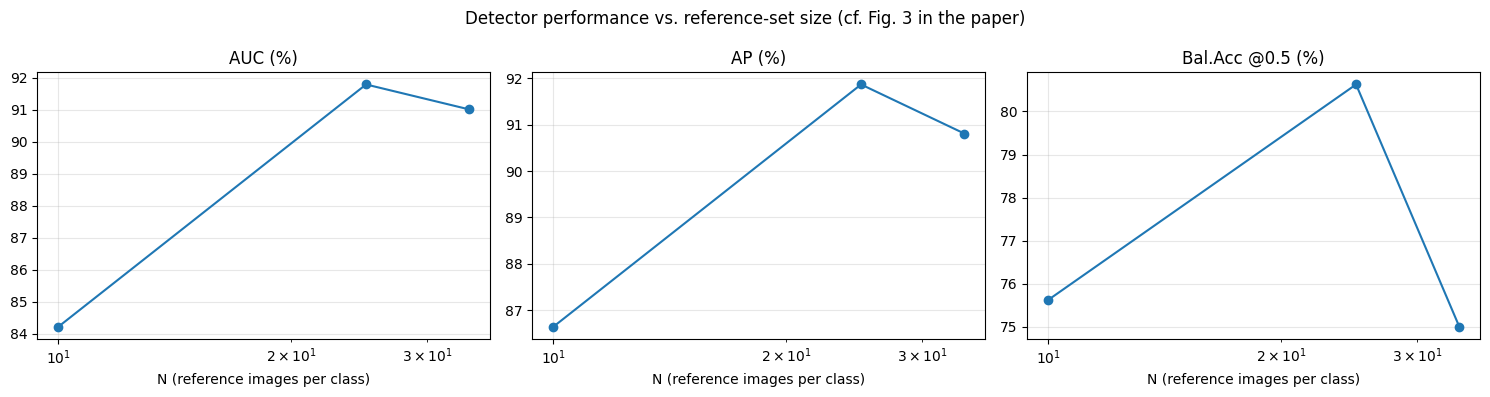

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, df_sweep.columns):
    ax.plot(df_sweep.index, df_sweep[metric], marker="o")
    ax.set_xscale("log")
    ax.set_xlabel("N (reference images per class)")
    ax.set_title(metric)
    ax.grid(alpha=0.3)
fig.suptitle("Detector performance vs. reference-set size (cf. Fig. 3 in the paper)")
plt.tight_layout()
plt.show()

## 6. Robustness to social-media-style processing

Section 3 of the paper evaluates robustness with a specific post-processing recipe applied at test time: a **random crop** covering between 5/8 and the full image area, **resize to 200×200**, then **JPEG re-compression** at a random quality between 65 and 100. We recreate that exact recipe and re-evaluate the *same* SVM (trained only on original images) on post-processed test images.

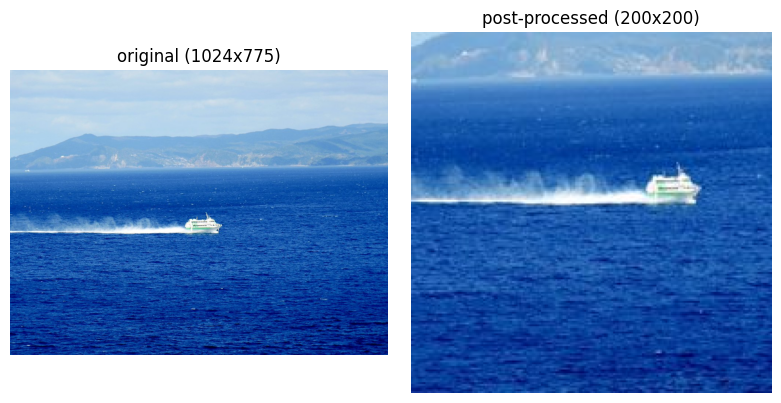

In [ ]:
def apply_paper_postprocessing(img, seed=None):
    """Random crop (5/8-1.0 of area) -> resize to 200x200 -> JPEG re-compression (quality 65-100)."""
    rng = random.Random(seed)
    img = img.convert("RGB")
    w, h = img.size
    ratio = rng.uniform(5 / 8, 1.0)
    cw, ch = max(int(w * ratio), 1), max(int(h * ratio), 1)
    left = rng.randint(0, max(w - cw, 0))
    top = rng.randint(0, max(h - ch, 0))
    img = img.crop((left, top, left + cw, top + ch))
    img = img.resize((200, 200), Image.BICUBIC)
    quality = rng.randint(65, 100)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def load_postprocessed_images(paths, seed=0):
    return [apply_paper_postprocessing(Image.open(p), seed=seed * 1000003 + i) for i, p in enumerate(paths)]


# visualize one example
example = Image.open(real_test_paths[0]).convert("RGB")
example_pp = apply_paper_postprocessing(example, seed=123)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(example); axes[0].set_title(f"original ({example.size[0]}x{example.size[1]})"); axes[0].axis("off")
axes[1].imshow(example_pp); axes[1].set_title(f"post-processed ({example_pp.size[0]}x{example_pp.size[1]})"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
pp_real_test_images = load_postprocessed_images(real_test_paths, seed=1)
pp_fake_test_images = load_postprocessed_images(fake_test_paths, seed=2)

real_feats_test_pp = clip_extractor.extract_from_images(pp_real_test_images, batch_size=CONFIG["batch_size"], desc="CLIP features (real, post-processed)")
fake_feats_test_pp = clip_extractor.extract_from_images(pp_fake_test_images, batch_size=CONFIG["batch_size"], desc="CLIP features (fake, post-processed)")

Xt_pp = scaler_clip.transform(np.concatenate([real_feats_test_pp, fake_feats_test_pp], axis=0))
yt_pp = np.concatenate([np.zeros(len(real_feats_test_pp)), np.ones(len(fake_feats_test_pp))])
scores_clip_test_pp = clf_clip.decision_function(Xt_pp)

metrics_clip_pp = {
    "AUC (%)": roc_auc_score(yt_pp, scores_clip_test_pp) * 100,
    "AP (%)": average_precision_score(yt_pp, scores_clip_test_pp) * 100,
    "Bal.Acc @0.5 (%)": balanced_accuracy_score(yt_pp, scores_clip_test_pp > 0) * 100,
}

pd.DataFrame([metrics_clip, metrics_clip_pp], index=["original", "post-processed (crop+resize+JPEG)"]).round(1)

CLIP features (real, post-processed):   0%|          | 0/1 [00:00<?, ?it/s]

CLIP features (fake, post-processed):   0%|          | 0/1 [00:00<?, ?it/s]

,AUC (%),AP (%),Bal.Acc @0.5 (%)
original,91.0,90.8,75.0
post-processed (crop+resize+JPEG),94.9,94.2,84.4


## 7. Related-work baselines: is CLIP actually special here?

This is the "tests on related papers' models" part. Rather than just reading that CLIP generalizes better, we test it directly: swap CLIP's feature extractor for two different backbones **representing the two main pre-CLIP forensic lineages** discussed in the paper's related work, and run them through the *exact same* reference-set → SVM → evaluation pipeline as above.

- **ImageNet-ResNet50** — a conventional supervised CNN backbone, in the spirit of Wang et al. (CVPR 2020) and Gragnaniello et al. (ICME 2021), which fine-tune/probe CNN features for real-vs-fake classification.
- **Hand-crafted frequency-domain features** — the azimuthally-averaged log power spectrum of each image, in the spirit of the classical GAN/DM "fingerprint" literature (Zhang et al., WIFS 2019; Durall et al., CVPR 2020; Frank et al., ICML 2020) — this family of methods is also what the paper's own Section 6 / Fig. 5 spectral analysis is discussing.

Both baselines use the same `StandardScaler + LinearSVC` recipe as the CLIP detector, so any performance gap reflects the *features*, not the classifier.

In [ ]:
class ImageNetResNetExtractor:
    """Classic CNN baseline: ImageNet-pretrained ResNet-50, penultimate (2048-d) layer."""

    def __init__(self, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Identity()
        m.eval().to(self.device)
        self.backbone = m
        self.num_features = 2048
        self.preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    @torch.no_grad()
    def extract_from_images(self, pil_images, batch_size=32, show_progress=True, desc="ResNet50 features"):
        feats = []
        iterator = range(0, len(pil_images), batch_size)
        if show_progress:
            iterator = tqdm(iterator, desc=desc)
        for i in iterator:
            batch_imgs = pil_images[i:i + batch_size]
            imgs = [self.preprocess(im.convert("RGB")) for im in batch_imgs]
            batch = torch.stack(imgs, 0).to(self.device)
            f = F.normalize(self.backbone(batch), dim=-1)
            feats.append(f.cpu().numpy())
        return np.concatenate(feats, axis=0)

    def extract_from_paths(self, paths, batch_size=32, show_progress=True, desc="ResNet50 features"):
        images = [Image.open(p) for p in paths]
        return self.extract_from_images(images, batch_size=batch_size, show_progress=show_progress, desc=desc)


class FrequencyDomainExtractor:
    """
    Classical spectral baseline: azimuthally-averaged log power spectrum of the
    grayscale image, binned into a fixed-length vector.
    """

    def __init__(self, n_bins=100, image_size=256):
        self.num_features = n_bins
        self.n_bins = n_bins
        self.image_size = image_size

    def _azimuthal_average_spectrum(self, img_gray):
        f = np.fft.fft2(img_gray)
        fshift = np.fft.fftshift(f)
        mag = np.log(np.abs(fshift) + 1e-8)
        h, w = mag.shape
        cy, cx = h // 2, w // 2
        y, x = np.indices((h, w))
        r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
        r_max = min(cy, cx)
        bin_edges = np.linspace(0, r_max, self.n_bins + 1)
        radial_mean = np.zeros(self.n_bins, dtype=np.float32)
        for i in range(self.n_bins):
            mask = (r >= bin_edges[i]) & (r < bin_edges[i + 1])
            if mask.any():
                radial_mean[i] = mag[mask].mean()
        return radial_mean

    def extract_from_images(self, pil_images, batch_size=None, show_progress=True, desc="Frequency-domain features"):
        iterator = tqdm(pil_images, desc=desc) if show_progress else pil_images
        feats = []
        for im in iterator:
            g = im.convert("L").resize((self.image_size, self.image_size), Image.BICUBIC)
            feats.append(self._azimuthal_average_spectrum(np.asarray(g, dtype=np.float32)))
        return np.stack(feats, axis=0)

    def extract_from_paths(self, paths, batch_size=None, show_progress=True, desc="Frequency-domain features"):
        images = [Image.open(p) for p in paths]
        return self.extract_from_images(images, show_progress=show_progress, desc=desc)


resnet_extractor = ImageNetResNetExtractor(device=CONFIG["device"])
freq_extractor = FrequencyDomainExtractor()
print("Baseline feature extractors ready.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Baseline feature extractors ready.


In [ ]:
LABEL_CLIP = "CLIP ViT-L/14 (this paper)"
LABEL_RESNET = "ResNet-50 (ImageNet, classic CNN)"
LABEL_FREQ = "Frequency-domain (classic spectral)"

backbones = {LABEL_CLIP: clip_extractor, LABEL_RESNET: resnet_extractor, LABEL_FREQ: freq_extractor}

comparison_rows = []
score_cache = {}  # kept around for the fusion section (Part 8)

for name, extractor in backbones.items():
    if name == LABEL_CLIP:
        # reuse the features already extracted above -- no need to redo the expensive part
        rf_pool, ff_pool = real_feats_pool, fake_feats_pool
        rf_test, ff_test = real_feats_test, fake_feats_test
        rf_test_pp, ff_test_pp = real_feats_test_pp, fake_feats_test_pp
    else:
        rf_pool = extractor.extract_from_paths(real_ref_paths, desc=f"{name}: real ref")
        ff_pool = extractor.extract_from_paths(fake_ref_paths, desc=f"{name}: fake ref")
        rf_test = extractor.extract_from_paths(real_test_paths, desc=f"{name}: real test")
        ff_test = extractor.extract_from_paths(fake_test_paths, desc=f"{name}: fake test")
        rf_test_pp = extractor.extract_from_images(pp_real_test_images, desc=f"{name}: real test (post-proc.)")
        ff_test_pp = extractor.extract_from_images(pp_fake_test_images, desc=f"{name}: fake test (post-proc.)")

    clf, scaler, m, scores_test, y_common = train_and_eval(rf_pool, ff_pool, rf_test, ff_test)

    Xt_pp = scaler.transform(np.concatenate([rf_test_pp, ff_test_pp], axis=0))
    scores_test_pp = clf.decision_function(Xt_pp)
    auc_pp = roc_auc_score(y_common, scores_test_pp) * 100
    balacc_pp = balanced_accuracy_score(y_common, scores_test_pp > 0) * 100

    score_cache[name] = {"clf": clf, "scaler": scaler, "scores_test": scores_test,
                          "scores_test_pp": scores_test_pp, "y": y_common}

    comparison_rows.append({
        "backbone": name,
        "AUC": m["AUC (%)"], "AP": m["AP (%)"], "Bal.Acc": m["Bal.Acc @0.5 (%)"],
        "AUC (post-proc.)": auc_pp, "Bal.Acc (post-proc.)": balacc_pp,
    })

df_comparison = pd.DataFrame(comparison_rows).set_index("backbone").round(1)
df_comparison

ResNet-50 (ImageNet, classic CNN): real ref:   0%|          | 0/2 [00:00<?, ?it/s]

ResNet-50 (ImageNet, classic CNN): fake ref:   0%|          | 0/2 [00:00<?, ?it/s]

ResNet-50 (ImageNet, classic CNN): real test:   0%|          | 0/1 [00:00<?, ?it/s]

ResNet-50 (ImageNet, classic CNN): fake test:   0%|          | 0/1 [00:00<?, ?it/s]

ResNet-50 (ImageNet, classic CNN): real test (post-proc.):   0%|          | 0/1 [00:00<?, ?it/s]

...

Frequency-domain (classic spectral): real test:   0%|          | 0/16 [00:00<?, ?it/s]

Frequency-domain (classic spectral): fake test:   0%|          | 0/16 [00:00<?, ?it/s]

Frequency-domain (classic spectral): real test (post-proc.):   0%|          | 0/16 [00:00<?, ?it/s]

Frequency-domain (classic spectral): fake test (post-proc.):   0%|          | 0/16 [00:00<?, ?it/s]

,AUC,AP,Bal.Acc,AUC (post-proc.),Bal.Acc (post-proc.)
backbone,,,,,
CLIP ViT-L/14 (this paper),91.0,90.8,75.0,94.9,84.4
"ResNet-50 (ImageNet, classic CNN)",64.1,67.8,62.5,56.2,56.2
Frequency-domain (classic spectral),75.0,76.0,75.0,68.4,59.4


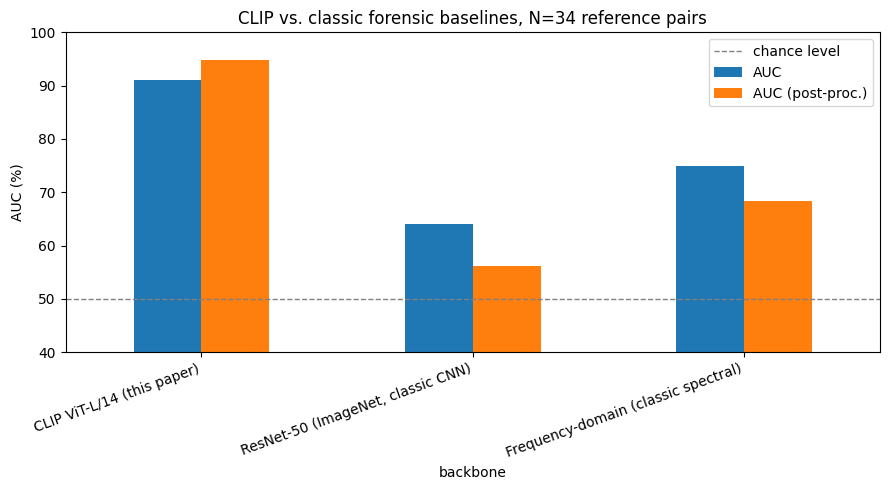

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
df_comparison[["AUC", "AUC (post-proc.)"]].plot(kind="bar", ax=ax)
ax.set_ylabel("AUC (%)")
ax.set_ylim(40, 100)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="chance level")
ax.set_title(f"CLIP vs. classic forensic baselines, N={len(real_ref_paths)} reference pairs")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Fusing detectors (paper Section 6)

The paper notes that combining CLIP with a low-level forensic detector can help, since their errors tend to be decorrelated: CLIP looks at high-level semantic/statistical cues, low-level detectors look at pixel-level noise fingerprints. They use a **"soft-OR"** rule — an image is called real only if *every* detector agrees it's real:

```
soft_or(x1, x2, ...) = -softminus_inv( sum_i log_sigmoid(-x_i) )
```

**Caveat:** this formula expects calibrated log-odds. `LinearSVC.decision_function` gives an uncalibrated margin instead, so we standardize each detector's scores first — a reasonable approximation for demonstration, though for rigorous use you'd calibrate with Platt scaling (`sklearn.calibration.CalibratedClassifierCV`).

In [ ]:
from scipy.special import log_expit


def soft_or_prob(logit_matrix, axis=-1):
    """'Declared real only if all detectors agree' fusion rule (paper, Section 6)."""
    softminusinv = lambda v: v - np.log(-np.expm1(v))
    log_p_real_per_detector = log_expit(-logit_matrix)
    log_p_all_real = np.sum(log_p_real_per_detector, axis=axis)
    return -softminusinv(log_p_all_real)


def to_logit_scale(s):
    return (s - s.mean()) / (s.std() + 1e-6) * 2.0


clip_scores = score_cache[LABEL_CLIP]["scores_test"]
freq_scores = score_cache[LABEL_FREQ]["scores_test"]
y_fusion = score_cache[LABEL_CLIP]["y"]

stacked = np.stack([to_logit_scale(clip_scores), to_logit_scale(freq_scores)], axis=-1)
fused_scores = soft_or_prob(stacked, axis=-1)

metrics_fused = {
    "AUC (%)": roc_auc_score(y_fusion, fused_scores) * 100,
    "AP (%)": average_precision_score(y_fusion, fused_scores) * 100,
    "Bal.Acc @0.5 (%)": balanced_accuracy_score(y_fusion, fused_scores > 0) * 100,
}
metrics_freq_alone = {
    "AUC (%)": roc_auc_score(y_fusion, freq_scores) * 100,
    "AP (%)": average_precision_score(y_fusion, freq_scores) * 100,
    "Bal.Acc @0.5 (%)": balanced_accuracy_score(y_fusion, freq_scores > 0) * 100,
}

pd.DataFrame({"CLIP alone": metrics_clip, "Frequency-domain alone": metrics_freq_alone,
              "Fused (soft-OR)": metrics_fused}).T.round(1)

,AUC (%),AP (%),Bal.Acc @0.5 (%)
CLIP alone,91.0,90.8,75.0
Frequency-domain alone,75.0,76.0,75.0
Fused (soft-OR),87.5,87.9,75.0


## 9. *(Bonus, optional)* Validate against the authors' own released weights

The official repo ships real pretrained weights (a `clipdet_latent10k_plus` linear head, and a `Corvi2023` ResNet50 detector — Corvi et al., ICASSP 2023, another directly related paper from the same group) via **Git LFS**. If we can pull them, we get the strongest possible validation of this recreation. If we can't — GitHub LFS has a shared *monthly bandwidth quota per repository*, so this can fail for reasons that have nothing to do with your setup — everything else in this notebook is unaffected.

In [ ]:
def try_load_official_models(clone_dir="ClipBased-SyntheticImageDetection"):
    repo_url = "https://github.com/grip-unina/ClipBased-SyntheticImageDetection.git"
    if not os.path.isdir(clone_dir):
        subprocess.run(["git", "clone", "--depth", "1", repo_url, clone_dir], check=False)
    subprocess.run(["git", "-C", clone_dir, "lfs", "install"], check=False)
    result = subprocess.run(["git", "-C", clone_dir, "lfs", "pull"], capture_output=True, text=True)
    print((result.stdout or "")[-1000:])
    print((result.stderr or "")[-1000:])

    sys.path.insert(0, clone_dir)
    try:
        import yaml
        from networks import create_architecture, load_weights

        def load_official(model_name):
            cfg_path = os.path.join(clone_dir, "weights", model_name, "config.yaml")
            with open(cfg_path) as f:
                cfg = yaml.safe_load(f)
            wpath = os.path.join(clone_dir, "weights", model_name, cfg["weights_file"])
            model = load_weights(create_architecture(cfg["arch"]), wpath)
            return model.eval().to(CONFIG["device"])

        clip_official = load_official("clipdet_latent10k_plus")
        corvi_official = load_official("Corvi2023")
        print("Loaded the official pretrained weights successfully!")
        return clip_official, corvi_official
    except Exception as e:
        print("Could not load the official weights (this is optional):", repr(e))
        print("This usually means GitHub LFS bandwidth is exhausted for this repo right now.")
        print("Everything else in this notebook is unaffected.")
        return None, None


clip_official, corvi_official = try_load_official_models()

open_clip_pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loaded the official pretrained weights successfully!


In [ ]:
if clip_official is not None:
    clip_transform_224 = transforms.Compose([
        transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                              std=(0.26862954, 0.26130258, 0.27577711)),
    ])

    @torch.no_grad()
    def run_official(model, paths, batch_size=16):
        outs = []
        for i in range(0, len(paths), batch_size):
            imgs = [clip_transform_224(Image.open(p).convert("RGB")) for p in paths[i:i + batch_size]]
            batch = torch.stack(imgs, 0).to(CONFIG["device"])
            out = model(batch).cpu().numpy()
            outs.append(out[:, 0])
        return np.concatenate(outs)

    real_scores_off = run_official(clip_official, real_test_paths)
    fake_scores_off = run_official(clip_official, fake_test_paths)
    y_off = np.concatenate([np.zeros(len(real_scores_off)), np.ones(len(fake_scores_off))])
    scores_off = np.concatenate([real_scores_off, fake_scores_off])
    auc_off = roc_auc_score(y_off, scores_off) * 100

    print(f"Official clipdet_latent10k_plus AUC on your held-out test set : {auc_off:.1f}%")
    print(f"Our from-scratch CLIP + SVM AUC on the same test set          : {metrics_clip['AUC (%)']:.1f}%")
    print("(The official model was trained on ~10k Latent-Diffusion images, so it may well")
    print(" outperform our small from-scratch reference set -- that gap is itself informative")
    print(" about how much N matters, echoing Part 5 above.)")
else:
    print("Official weights weren't loaded in the previous cell -- nothing to compare here. Skip ahead.")

Official clipdet_latent10k_plus AUC on your held-out test set : 73.0%
Our from-scratch CLIP + SVM AUC on the same test set          : 91.0%
(The official model was trained on ~10k Latent-Diffusion images, so it may well
 outperform our small from-scratch reference set -- that gap is itself informative
 about how much N matters, echoing Part 5 above.)


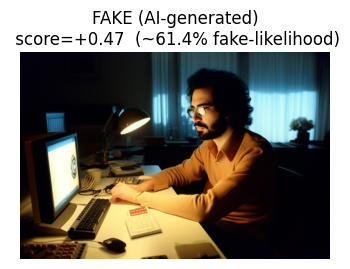

{'label': 'FAKE (AI-generated)',
 'score': 0.4650461995328115,
 'fake_likelihood_pct': 61.42105900884327}

In [ ]:
def predict_image(path_or_pil, clf=clf_clip, scaler=scaler_clip, extractor=clip_extractor, show=True):
    """
    Runs the trained CLIP + SVM detector on a single image.
    Accepts a file path (str) or an already-loaded PIL Image.
    """
    img = Image.open(path_or_pil).convert("RGB") if isinstance(path_or_pil, str) else path_or_pil.convert("RGB")

    feat = extractor.extract_from_images([img], batch_size=1, show_progress=False)
    feat_scaled = scaler.transform(feat)
    score = clf.decision_function(feat_scaled)[0]  # > 0 means "predicted fake"

    # NOTE: this turns the raw SVM margin into a 0-100% figure for intuition only --
    # it is *not* a calibrated probability (see the calibration caveat in Part 8).
    fake_likelihood = 1 / (1 + np.exp(-score)) * 100
    label = "FAKE (AI-generated)" if score > 0 else "REAL"

    if show:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{label}\n score={score:+.2f}  (~{fake_likelihood:.1f}% fake-likelihood)")
        plt.show()
    else:
        print(f"{label}  |  score={score:+.2f}  |  ~{fake_likelihood:.1f}% fake-likelihood")

    return {"label": label, "score": float(score), "fake_likelihood_pct": float(fake_likelihood)}


# --- Option 1: predict on one of your held-out test images ---
#predict_image(real_test_paths[0])
#predict_image(fake_test_paths[0])

# --- Option 2: upload your own image to test (Colab only) ---
# from google.colab import files
# uploaded = files.upload()
# predict_image(list(uploaded.keys())[0])

# --- Option 3: point at any local file path ---
predict_image("/content/data/fake/synthwildx_midjourney_v5/F-0U2WDXkAAaKOI.jpg")

## 10. Summary, and adapting this to your own project

**What this notebook recreated:**

| Paper section | Notebook part |
|---|---|
| Sec. 4, feature extraction (next-to-last CLIP layer) | Part 1 |
| Sec. 4, reference set + linear SVM | Parts 3–4 |
| Fig. 3, performance vs. N | Part 5 |
| Sec. 3, robustness protocol (crop/resize/JPEG) | Part 6 |
| Related work (CNN and spectral baselines) | Part 7 |
| Sec. 6, detector fusion | Part 8 |
| Released weights (`clipdet_latent10k_plus`, Corvi2023) | Part 9 |

**To adapt this for your own project:**
- Swap in your own generator's output as `data/fake/*` and real reference photos as `data/real/*` — that's literally the whole retraining procedure (Part 3–4 again).
- Push `CONFIG["max_reference_pairs"]` up toward the paper's 1k–10k regime once you have that much data; Part 5's sweep shows you where the returns start to flatten for your own data.
- Try `CONFIG["pretrained_tag"] = "clipL14commonpool"` and re-run Part 1 onward — Fig. 4 of the paper shows this is the best-generalizing pretraining, at the cost of a bigger download.
- Save your trained detector (next cell) and reuse it outside the notebook, e.g. in a lightweight inference script.

**References**
- Cozzolino, Poggi, Corvi, Nießner, Verdoliva. *Raising the Bar of AI-generated Image Detection with CLIP.* CVPRW 2024. [arXiv:2312.00195](https://arxiv.org/abs/2312.00195)
- Official code: [github.com/grip-unina/ClipBased-SyntheticImageDetection](https://github.com/grip-unina/ClipBased-SyntheticImageDetection)
- Corvi et al. *On the detection of synthetic images generated by diffusion models.* ICASSP 2023.
- Wang et al. *CNN-generated images are surprisingly easy to spot... for now.* CVPR 2020.
- Ojha et al. *Towards universal fake image detectors that generalize across generative models.* CVPR 2023.
- Demo dataset: [huggingface.co/datasets/Parveshiiii/AI-vs-Real](https://huggingface.co/datasets/Parveshiiii/AI-vs-Real)

In [ ]:
import joblib

os.makedirs("outputs", exist_ok=True)
joblib.dump(
    {"clf": clf_clip, "scaler": scaler_clip, "pretrained_tag": CONFIG["pretrained_tag"]},
    "outputs/clip_svm_detector.joblib",
)
print("Saved trained detector to outputs/clip_svm_detector.joblib")
print("Reload later with: joblib.load('outputs/clip_svm_detector.joblib')")

Saved trained detector to outputs/clip_svm_detector.joblib
Reload later with: joblib.load('outputs/clip_svm_detector.joblib')
